# Filtering the images


Read from articles_filtered.csv and copy the images it has to folder images_filtered

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
data_path = Path('../raw_data/')

In [2]:
articles_df = pd.read_csv(data_path / 'articles_filtered.csv')
trans_df = pd.read_csv(data_path / 'transactions_filtered.csv')

In [3]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738255 entries, 0 to 738254
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        738255 non-null  int64  
 1   t_dat             738255 non-null  object 
 2   customer_id       738255 non-null  object 
 3   article_id        738255 non-null  int64  
 4   price             738255 non-null  float64
 5   sales_channel_id  738255 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 33.8+ MB


In [4]:
trans_df = trans_df[['t_dat', 'article_id', 'price', 'customer_id']]
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738255 entries, 0 to 738254
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   t_dat        738255 non-null  object 
 1   article_id   738255 non-null  int64  
 2   price        738255 non-null  float64
 3   customer_id  738255 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 22.5+ MB


In [5]:
trans_df['t_dat']= pd.to_datetime(trans_df['t_dat'])
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738255 entries, 0 to 738254
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   t_dat        738255 non-null  datetime64[ns]
 1   article_id   738255 non-null  int64         
 2   price        738255 non-null  float64       
 3   customer_id  738255 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 22.5+ MB


In [6]:
articles_df.columns

Index(['Unnamed: 0', 'article_id', 'product_code', 'prod_name',
       'product_type_no', 'product_type_name', 'product_group_name',
       'graphical_appearance_no', 'graphical_appearance_name',
       'colour_group_code', 'colour_group_name', 'perceived_colour_value_id',
       'perceived_colour_value_name', 'perceived_colour_master_id',
       'perceived_colour_master_name', 'department_no', 'department_name',
       'index_code', 'index_name', 'index_group_no', 'index_group_name',
       'section_no', 'section_name', 'garment_group_no', 'garment_group_name',
       'detail_desc'],
      dtype='object')

In [7]:
articles_df['perceived_colour_master_name'].unique()

array(['Brown', 'undefined', 'White', 'Black', 'Blue', 'Grey', 'Pink',
       'Yellow', 'Red', 'Beige', 'Orange', 'Mole', 'Green', 'Khaki green',
       'Metal', 'Lilac Purple', 'Turquoise', 'Unknown'], dtype=object)

In [8]:
articles_df[['article_id', 'product_code','perceived_colour_value_id']]

,article_id,product_code,perceived_colour_value_id
0,181160009,181160,2
1,212042036,212042,6
2,212042070,212042,3
3,258650001,258650,4
4,264713001,264713,4
...,...,...,...
5151,938190001,938190,2
5152,938190002,938190,4
5153,939279001,939279,4
5154,947310001,947310,2


## Testing helper_functions

In [9]:
article_id = 181160009
image_path = Path("../raw_data/images_filtered/")
article_str = str(article_id).zfill(10)

In [10]:
article_str

'0181160009'

In [11]:
subfolder = article_str[:3]
subfolder

'018'

In [12]:
dict_t = {0: 'No Color', 1: 'Black', 2: 'Blue'}


In [13]:
articles_df['product_type_name'].unique()

array(['Boots', 'Sneakers', 'Other shoe', 'Sandals', 'Slippers',
       'Ballerinas', 'Flat shoe', 'Wedge', 'Pumps', 'Flip flop', 'Bootie',
       'Heeled sandals', 'Flat shoes', 'Heels', 'Moccasins',
       'Pre-walkers'], dtype=object)

In [14]:
articles_df['index_group_name'].unique()

array(['Divided', 'Menswear', 'Ladieswear', 'Baby/Children', 'Sport'],
      dtype=object)

In [15]:
import os
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

NameError: name '__file__' is not defined

In [ ]:
BASE_DIR

In [9]:
from shoppingassistant.clustering import similar_items, build_chroma_collection
from shoppingassistant.helper_functions import get_image_path
from shoppingassistant.process_data import load_dataframes

articles_df, transactions_df = load_dataframes()
article_id = articles_df.iloc[0]['article_id']
image_path = get_image_path(article_id)
print(f"Image path for article ID {article_id}: {image_path}")
image = "../raw_data/test_images/test1.jpeg"
articles_df["product_type_name"].unique()

✅ Filtered data already exists.
Image path for article ID 181160009: ../raw_data/images_filtered/018/0181160009.jpg


array(['Boots', 'Sneakers', 'Other shoe', 'Sandals', 'Slippers',
       'Ballerinas', 'Flat shoe', 'Wedge', 'Pumps', 'Flip flop', 'Bootie',
       'Heeled sandals', 'Flat shoes', 'Heels', 'Moccasins',
       'Pre-walkers'], dtype=object)

In [2]:
output = similar_items(image, n=5, subcategory='Sneakers', gender='Menswear')
output

ChromaDB collection already populated by 5156. Skipping build.


/home/anas/.pyenv/versions/shoppingassistant-env/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[{'article_id': 522678003,
  'filename': '0522678003.jpg',
  'image_path': '/home/anas/code/Anas-sel/shopping-assistant/raw_data/images_filtered/052/0522678003.jpg',
  'similarity': 0.9495704174041748,
  'prod_name': 'Art leather sneaker PQ',
  'product_type_name': 'Sneakers',
  'colour_group_name': 'White',
  'index_group_name': 'Menswear'},
 {'article_id': 671809001,
  'filename': '0671809001.jpg',
  'image_path': '/home/anas/code/Anas-sel/shopping-assistant/raw_data/images_filtered/067/0671809001.jpg',
  'similarity': 0.9316394329071045,
  'prod_name': 'Malin court sneaker',
  'product_type_name': 'Sneakers',
  'colour_group_name': 'Off White',
  'index_group_name': 'Menswear'},
 {'article_id': 601769005,
  'filename': '0601769005.jpg',
  'image_path': '/home/anas/code/Anas-sel/shopping-assistant/raw_data/images_filtered/060/0601769005.jpg',
  'similarity': 0.9238752126693726,
  'prod_name': 'Cirrus knit court sneaker',
  'product_type_name': 'Sneakers',
  'colour_group_name': 'Whit

In [ ]:
from shoppingassistant.helper_functions import get_image_path


In [4]:
article_id = '0319906006.jpg'

In [6]:
from pathlib import Path
image_path = Path("../raw_data/images_filtered/")
article_str = str(article_id).zfill(10)
article_str = article_str.replace('.jpg', '')


In [7]:
subfolder = article_str[:3]
image_file = image_path / subfolder / f"{article_str}.jpg"
image_file

PosixPath('../raw_data/images_filtered/031/0319906006.jpg')

In [10]:
image_file.exists()

True

✅ Filtered data already exists.
Image path for article ID 319906006: ../raw_data/images_filtered/031/0319906006.jpg
ChromaDB collection already populated by 5156. Skipping build.


FileNotFoundError: Image for article_id 0319906006.jpg not found.

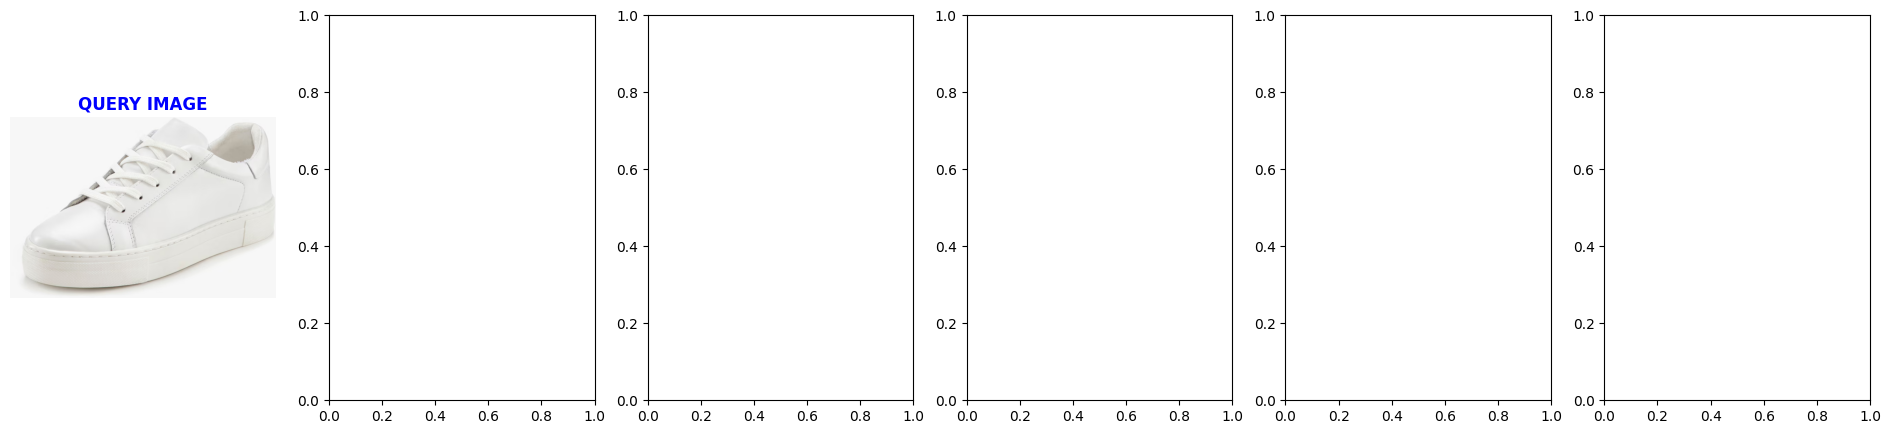

In [7]:
from shoppingassistant.clustering import similar_items
from shoppingassistant.helper_functions import get_image_path, display_results
from shoppingassistant.process_data import load_dataframes

articles_df, transactions_df = load_dataframes()
article_id = articles_df.iloc[10]['article_id']
image_path = get_image_path(article_id)
print(f"Image path for article ID {article_id}: {image_path}")
image = "../raw_data/test_images/test1.jpg"
output = similar_items(image_path, n=5)
display_results(image, output)